In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [6]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()

class_names=["airplane",'automobile','bird','cat','deer','dog',
             'frog','horse','ship','truck']

In [7]:
X_train=X_train/255.0
X_test=X_test/255.0

In [8]:
model=models.Sequential()
model.add(layers.Conv2D(128,(5,5),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(5,5),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128,(5,5),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(5,5),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10,activation='softmax'))

ValueError: Computed output size would be negative. Received `inputs shape=(None, 0, 0, 128)`, `kernel shape=(5, 5, 128, 128)`, `dilation_rate=[1 1]`.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 0, 0, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 0, 0, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 0)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,306 (153.54 KB)

 Trainable params: 39,306 (153.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train,epochs=15,batch_size=64,validation_data=(X_test,y_test))

Epoch 1/5


ValueError: Exception encountered when calling Conv2D.call().

[1mNegative dimension size caused by subtracting 3 from 2 for '{{node sequential_1/conv2d_3_1/convolution}} = Conv2D[T=DT_FLOAT, data_format="NHWC", dilations=[1, 1, 1, 1], explicit_paddings=[], padding="VALID", strides=[1, 1, 1, 1], use_cudnn_on_gpu=true](sequential_1/max_pooling2d_2_1/MaxPool2d, sequential_1/conv2d_3_1/convolution/ReadVariableOp)' with input shapes: [?,2,2,32], [3,3,32,64].[0m

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(None, 2, 2, 32), dtype=float32)

1. Add 2 more CONV layers
2. Increase filters (64 -> 128)
3. Add Dropout
4. Change Kernel Size
5. Increase Epochs
6. Use validation_split instead of validation_data
7. Evaluate model on Test Data

In [18]:
# Improved CNN Model with all requested enhancements
model_improved = models.Sequential()

# First Conv Block - kernel size 3x3
model_improved.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))


# Second Conv Block - kernel size 3x3 (increased filters to 128)
model_improved.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model_improved.add(layers.MaxPooling2D((2, 2)))
model_improved.add(layers.Dropout(0.3))

# Third Conv Block - kernel size 3x3 (increased filters to 256)
model_improved.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model_improved.add(layers.MaxPooling2D((2, 2)))
model_improved.add(layers.Dropout(0.4))

# Flatten
model_improved.add(layers.Flatten())

# Dense Layers
model_improved.add(layers.Dense(512, activation='relu'))
model_improved.add(layers.Dropout(0.5))
model_improved.add(layers.Dense(256, activation='relu'))
model_improved.add(layers.Dropout(0.5))

# Output Layer
model_improved.add(layers.Dense(10, activation='softmax'))

model_improved.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,371,050 (5.23 MB)

 Trainable params: 1,371,050 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile the improved model
model_improved.compile(optimizer='adam', 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])

In [20]:
# Train with validation_split (instead of validation_data) and increased epochs
history_improved = model_improved.fit(X_train, y_train, 
                                     epochs=100,  # Increased from 15 to 25
                                     batch_size=64, 
                                     validation_split=0.2)  # Using validation_split instead of validation_data

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.2394 - loss: 2.0142 - val_accuracy: 0.5053 - val_loss: 1.3732
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.2394 - loss: 2.0142 - val_accuracy: 0.5053 - val_loss: 1.3732
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4905 - loss: 1.4197 - val_accuracy: 0.6046 - val_loss: 1.1066
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4905 - loss: 1.4197 - val_accuracy: 0.6046 - val_loss: 1.1066
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5633 - loss: 1.2219 - val_accuracy: 0.6420 - val_loss: 1.0313
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5633 - loss: 1.2219 - val_accuracy: 0.6420 - val_loss: 1.0313
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6074 - loss: 1.1135 - val_accuracy: 0.6749 - val_loss: 0.9326
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6074 - loss: 1

In [12]:
# Evaluate model on Test Data
test_loss, test_accuracy = model_improved.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1006 - loss: 2.3026

Test Accuracy: 0.1000
Test Loss: 2.3026
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1006 - loss: 2.3026

Test Accuracy: 0.1000
Test Loss: 2.3026


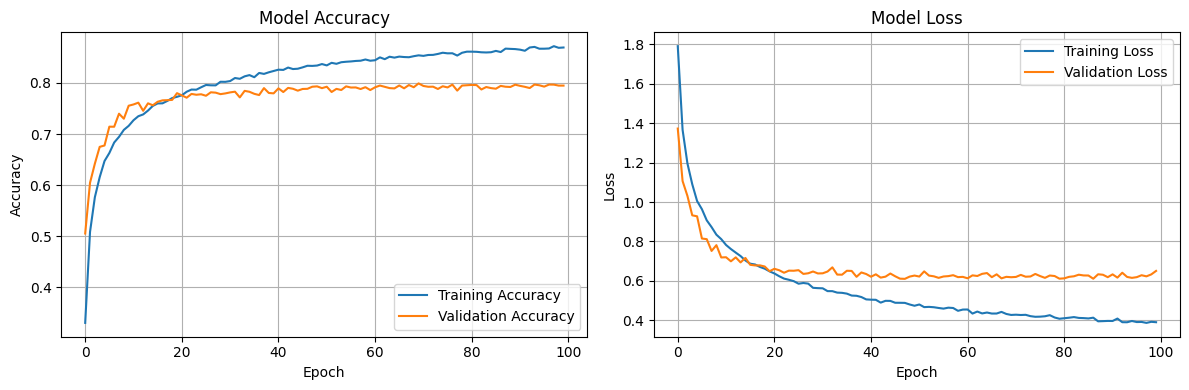

In [21]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()